# Análisis de Tarjetas de Crédito

## 1.- Carga de librerías y funciones

In [153]:
#1.- Importacón de librerías y definiciónd de funciones
import pandas as pd
import matplotlib.pyplot as plt

def monthly_summary(df: pd.DataFrame, group_by ="year_month") -> pd.DataFrame:
    """monthly_summary: Calcula métrias agregadas a partir de un DataFrame de contratos de tarjetas de crédito."""

    df_group = df.groupby(group_by)

    total_active_contracts = df_group["active_account"].sum()
    total_credit_limit = df_group["credit_limit"].sum()
    total_average_daily_balance = df_group["average_daily_balance"].sum()

    total_spending = df_group["spending"].sum()
    total_payments = df_group["payments"].sum()
    average_daily_balance_utilization = (total_average_daily_balance / total_credit_limit) * 100
    average_spending_utilization = (total_spending / total_credit_limit) * 100

    return pd.DataFrame({

  		"total_active_contracts": total_active_contracts,
		"total_active_contracts_percentage": total_active_contracts.pct_change() * 100,
  		"total_credit_limit": total_credit_limit,
    	"total_credit_limit_percentage": total_credit_limit.pct_change() * 100,
  		"total_average_daily_balance": total_average_daily_balance,
		"total_average_daily_balance_percentage": total_average_daily_balance.pct_change() * 100,
  		"total_spending": total_spending,
		"total_spending_percentage": total_spending.pct_change() * 100,
  		"total_payments": total_payments,
		"total_payments_percentage": total_payments.pct_change() * 100,

  		"average_daily_balance_utilization": average_daily_balance_utilization,
    	"average_daily_balance_utilization_diff": average_daily_balance_utilization.diff(),
		"average_spending_utilization": average_spending_utilization,
  		"average_spending_utilization_diff": average_spending_utilization.diff()
	})

def plot_total_statistics(df: pd.DataFrame, xlim_inf=6, xlim_sup=-1, options_plotting: dict = {
			"total_active_contracts": {"title": "Credit Card Contract", "color":"blue", "ylim":(0,30)},
			"total_credit_limit": {"title": "Total Credit Limit", "color":"orange", "ylim":(0,10)},
			"total_average_daily_balance": {"title": "Total Average Daily Balance", "color":"green", "ylim":(0,80)},
			"total_spending": {"title": "Total Spending", "color":"yellow", "ylim":(0,40)},
			"total_payments": {"title": "Total Payments", "color":"black", "ylim":(0,40)},
    	}) -> None:
	"""plot_total_statistics: Genera gráficas de las métricas totales."""

	fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(15, 25))
	indice = 0
	for column in options_plotting:
		options = options_plotting[column]
		df.plot(y=column, kind="bar", title=options["title"] + " Summary", grid=True, ax=axes[indice][0], color=options["color"])
		df.plot(y=column + "_percentage", title=options["title"] + " % Variation", grid=True, ax=axes[indice][1], color=options["color"])
		df.plot(y=column + "_percentage", title=options["title"] + " % Variation", grid=True, ax=axes[indice][2], color=options["color"], xlim=(xlim_inf, len(df) + xlim_sup), ylim=options["ylim"])
		indice += 1

	plt.tight_layout()
	for ax in axes.flat:
		for tick in ax.get_xticklabels():
			tick.set_rotation(90)
	plt.show()

def plot_average_statistics(df: pd.DataFrame) -> None:
	"""plot_average_statistics: Genera gráficas de las métricas relativass."""

	fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(11, 6), squeeze=False)
	df.plot(y="average_daily_balance_utilization", title="Average Daily Balance Utilization %", grid=True, ax=axes[0][0], color="red")
	df.plot(y="average_daily_balance_utilization_diff", title="Average Daily Balance Utilization Diff %", grid=True, ax=axes[0][1], color="red")
	df.plot(y="average_spending_utilization", title="Average Spending Utilization %", grid=True, ax=axes[1][0], color="purple")
	df.plot(y="average_spending_utilization_diff", title="Average Spending Utilization Diff %", grid=True, ax=axes[1][1], color="purple")

	plt.tight_layout()
	plt.show()

## 2.- Creación del dataframe

In [154]:
#2.- Lectura de archivo y limpieza de datos
df = pd.read_csv("Python Evaluation Dataset.csv")
df["payments"] = df["payments"].fillna(0)
df["activation_date"] = pd.to_datetime(df["activation_date"], format="%d/%m/%y")
df["month_end"] = pd.to_datetime(df["month_end"], format="%d/%m/%y")

## 3.- Cálculo del gasto por mes

Teniendo en cuenta $$closing\_balance=initial\_balance + spending - payments$$
Se tiene $$spending = closing\_balance -initial\_balance + payments$$

In [155]:
#3.- Cálculo de gasto mensual
df["spending"] = df["closing_balance"] - df["initial_balance"] + df["payments"]

#Ajuste de gastos negativos, si los hay se agregan como pagos
negative_spending_filter = df["spending"] < 0
df.loc[negative_spending_filter, "payments"] = df["payments"] - df["spending"]
df.loc[negative_spending_filter, "spending"] = 0

## 4.- Métricas mensuales

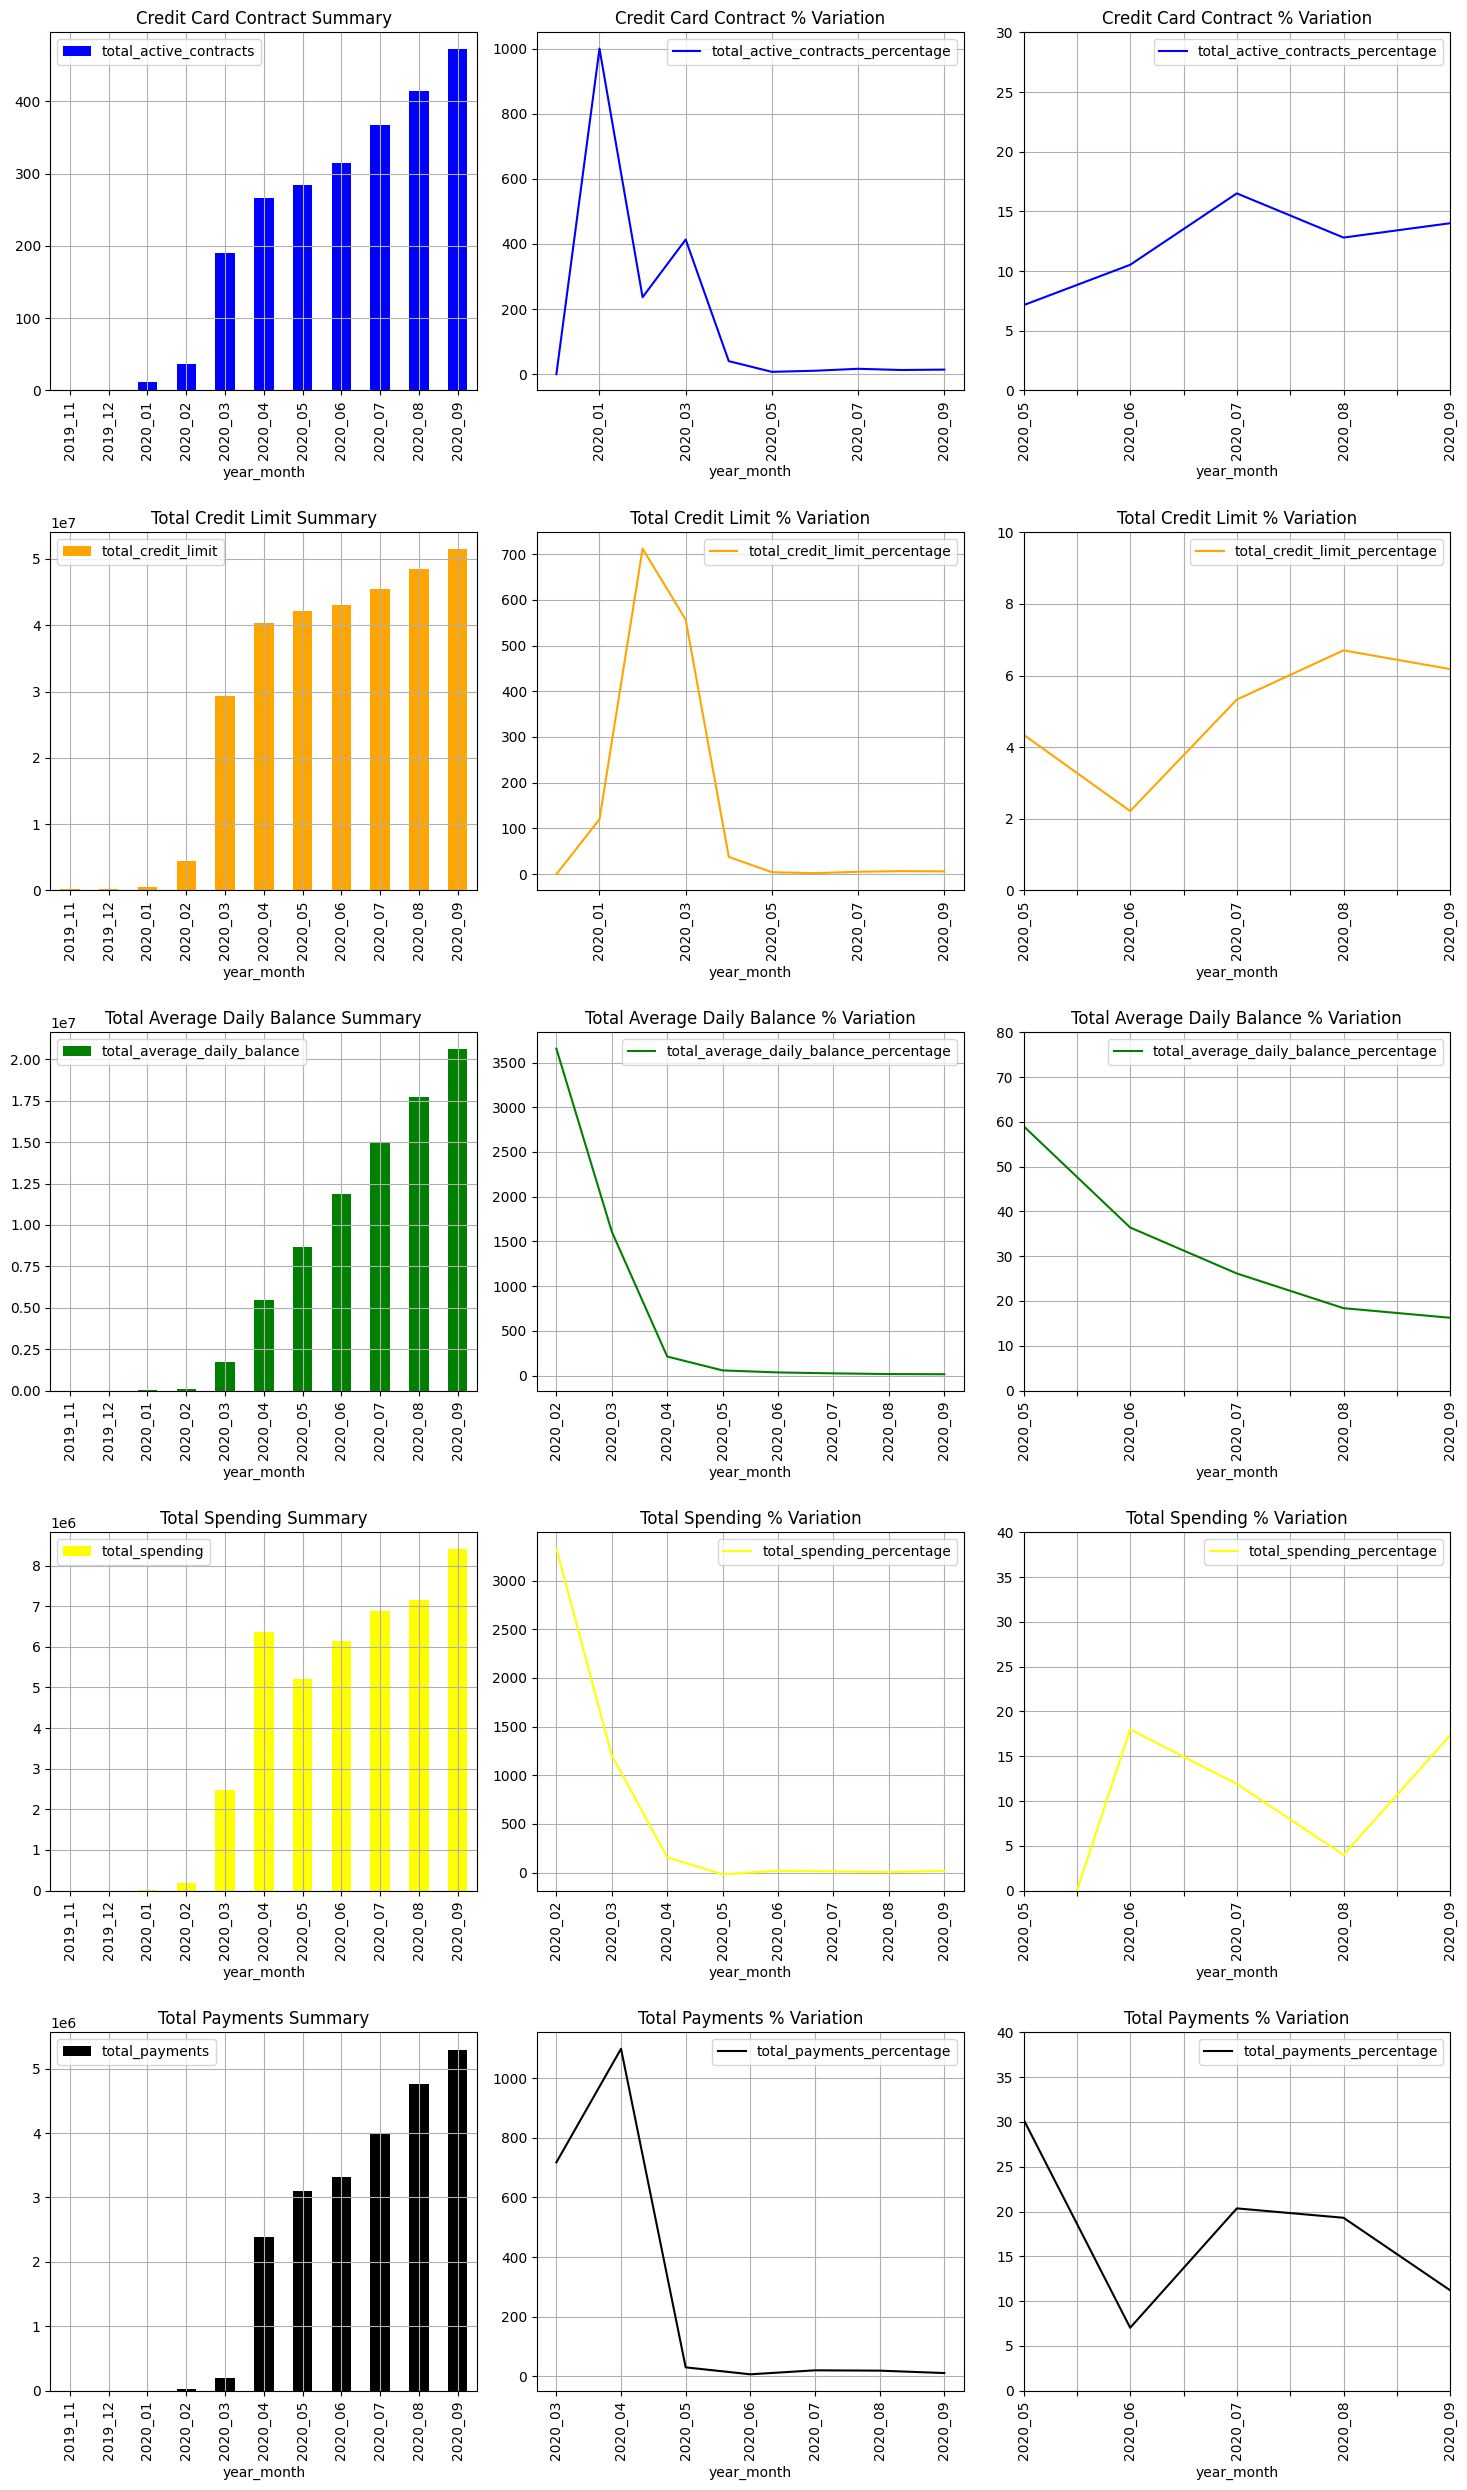

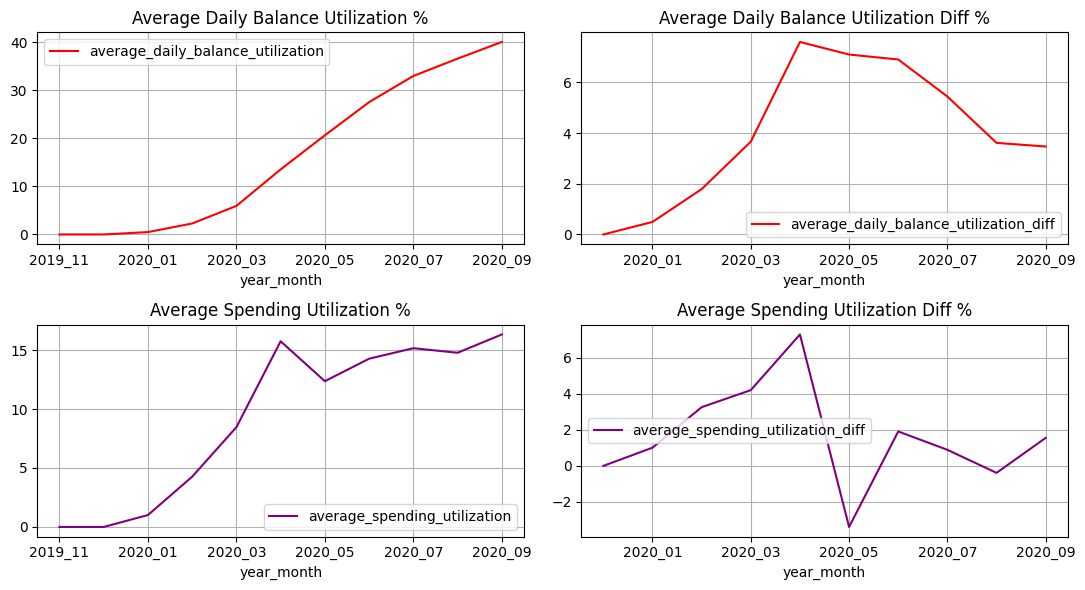

In [156]:
#4.- Estadísticas mensuales
df_group_summary = monthly_summary(df)
plot_total_statistics(df_group_summary)
plot_average_statistics(df_group_summary)

## 5.- Análisis del portafolio

### a) Cuentas activas

- Se identifica que el inicio de operaciones de las emisiones de tarjetas de crédito empezó en los últimos meses de diciembre de 2019, sin embargo, el lanzamiento formal se detecta en febrero de 2020 con la adquisición de los primeros clientes y en el siguiente mes la formalización del servicio con la adquisición de más de 100 clientes.
-  A partir de marzo y hasta el mes de corte de septiembre se muestra un aumento sostenido en las cuentas activas, lo que implica que cada mes se han obtenido nuevos clientes de la tarjeta de crédito. El porcentaje de crecimiento de nuevos clientes con respecto a cada periodo anterior está entre el 10% y 15%

### b) Total credit limit

- De manera similar a las cuentas activas se observa un aumento en el límite de crédito.
- A partir del periodo de estabilidad (mayo de 2020 en adelante), se observa que el crecimiento ronda entre el 2% y 7%
- Dado que el crecimiento es más lento que el crecimiento de las cuentas activas se percibe que si bien se acaparan nuevos clientes el crédito que se les otorga tiene un comportamiento conservador, lo que se puede inferir que la estrategia tiene como prioridad la obtención de nuevos clientes.

### c) Total spending
- Se osberva que el uso de la tarjeta se empieza a estabilizar a partir de abril del 2020 con 6 millones de pesos gastados a comparación de los 2 millones y medio de marzo. 
- También se nota que el uso de la tarjeta tuvo un periodo de adaptación, pues si bien hubo un crecimiento en el gasto del crédito, no sería hasta julio ue se superaría el monto de abril. Hay que tener en cuenta que si es un producto nuevo dirigido a clientes nuevos éstos muestren cautela en su uso hasta que se adaptan al uso y aumentan su gasto. Se tiene como ejemplo el mes de septiembre que superó el monto de los 8 millones.
- Si comparamos el gasto respecto al crédito otorgado total se observa que esta relación se encuentra en un umbral del 15%, lo que representa una cifra estable en el uso general del crédito

### d) Average daily balance
- Se observa que el total del saldo promedio mensual aumentó de manera sostenida en los primeros meses del servicio, dando paso a una estabilización en los últimos dos meses
- El rango de crecimiento si bien ha bajado (como consecuencia de la estabilización), se observa que el crecimiento al último mes fue de poco menos del 20%
- Con referencia al gráfico del Average Daily balance, se observa que el uso promedio de cada tarjeta de crédito está en torno al 40% al mes de septiembre. Esto implica que la fase de estabilización se ha dado de manera satisfactoria, ya que se muestra en la gráfica que el saldo promedio respecto al crédito disponible aumenta lo que refleja un mayor uso por parte de los clientes
- Si bien el total spending ha aumentado de manera cautelosa el average daily muestra que el banco puede obtener mayores utilidades por concepto de cobnro de intereses

### e) Conclusiones
- Se ha tenido un aumento general de los clientes lo que implica que el producto tiene buena aceptación
- El producto ha tenido una buena respuesta por parte de los clientes dado su mayor uso
- Al corte de septiembre de 2020 se observa que el gasto es mayor que los pagos, si bien esto es beneficioso en términos de cobro de intereses, no cabe de más vigilar está relación de manera que no caiga en una cartera de clientes riesgosa que pueda presentar una alta tasa de impago.
- Se puede concluir que la estrategia es conservadora en términos de crédito otorgado pero con una mayor apertura en la captación de nuevos clientes, lo que puede servir justamente para ir conociendo el comportamiento de los clientes y en un futuro poder realizar una segmentación para otorgar mayores créditos a los clientes actuales y/o promociones adicionales para seguir fomentando el uso del producto.
 

## 6.- Métricas mensuales de contratos activados en Marzo de 2020

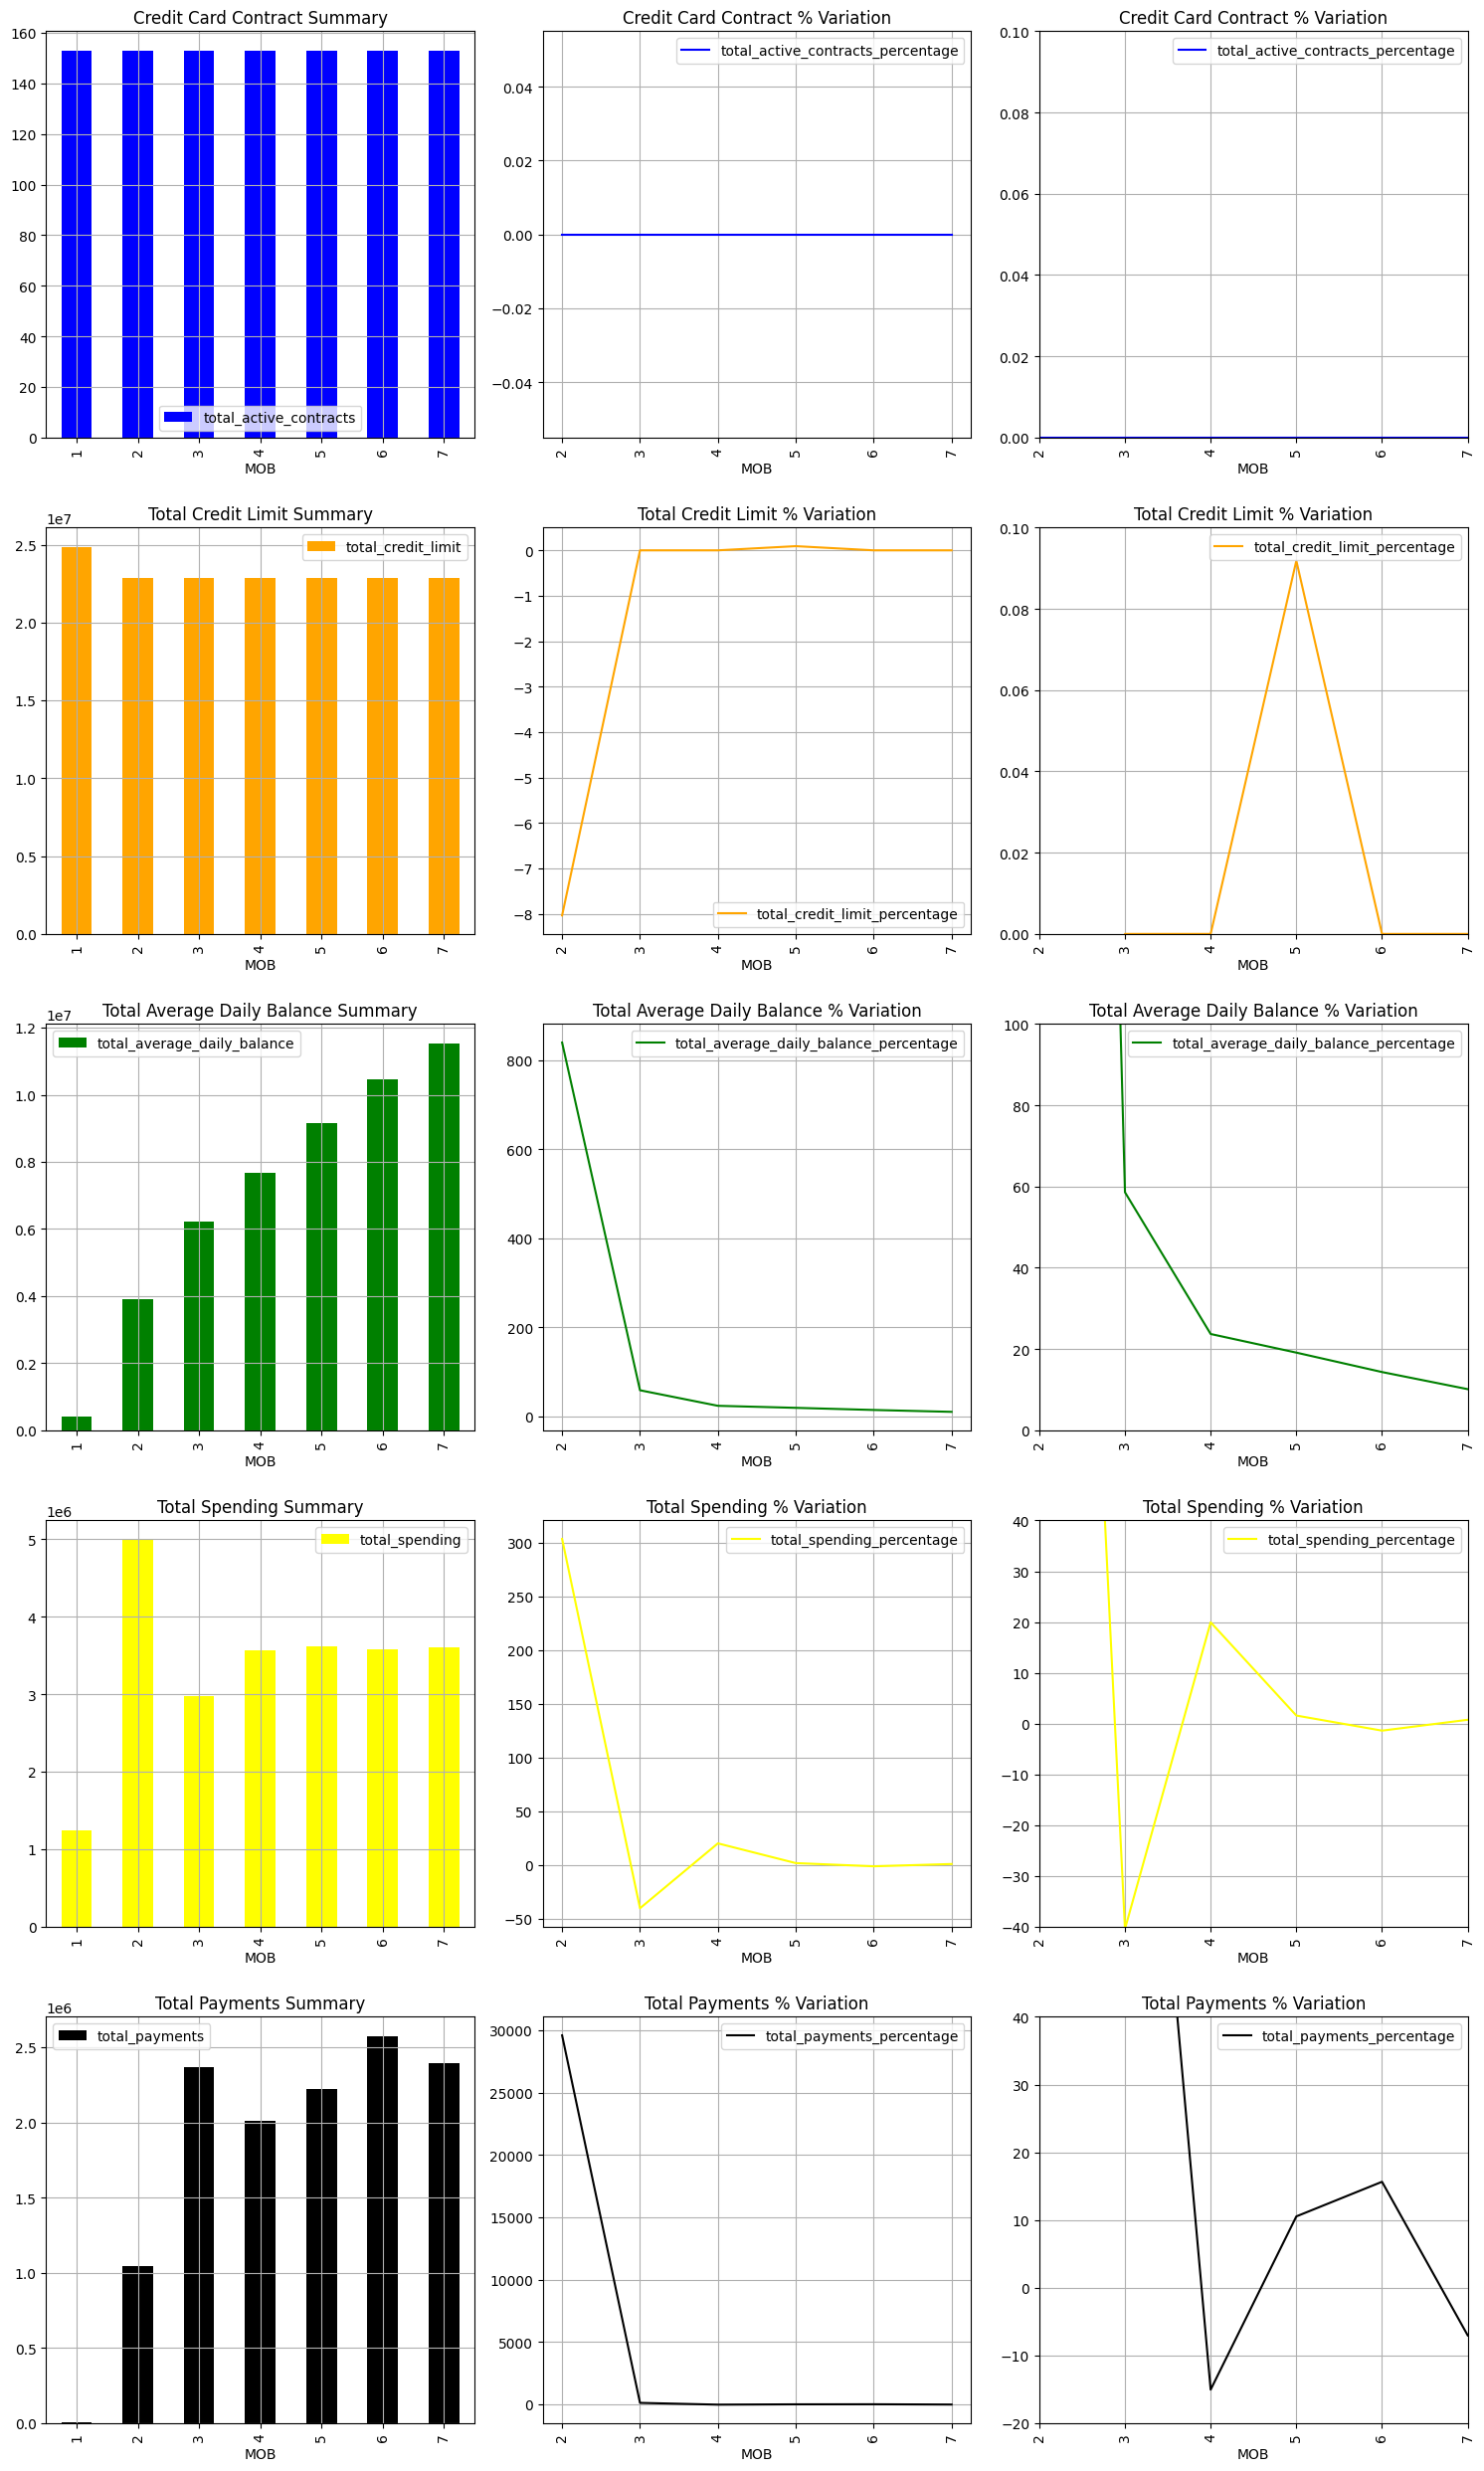

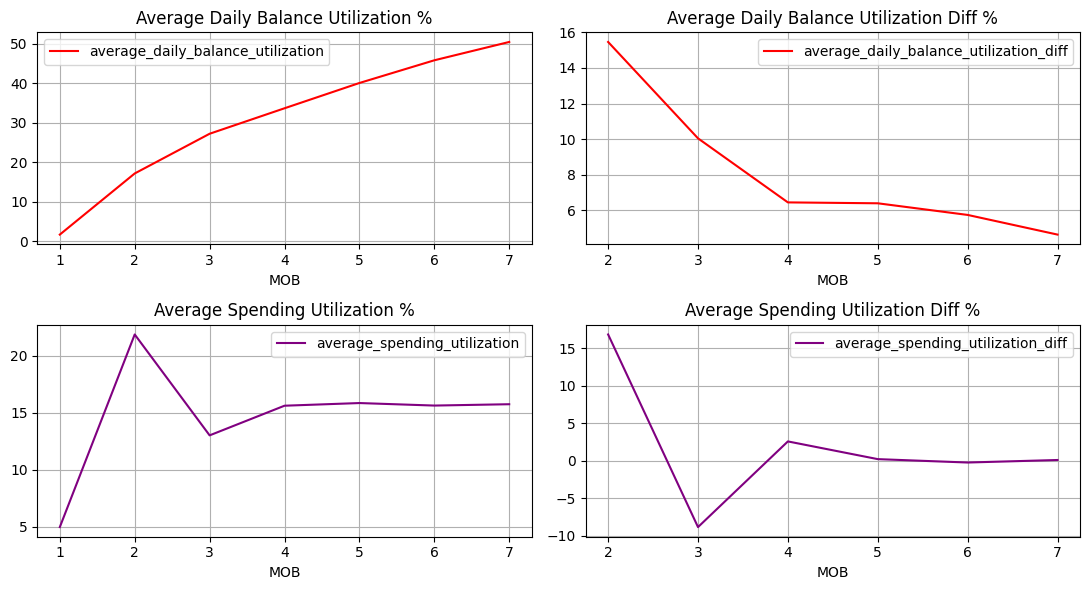

In [157]:
#5.- Estadísticas de tarjetas activadas en marzo de 2020
df_march = df[(df["activation_date"] >= "2020-03-01") & (df["activation_date"] <= "2020-03-31")]
df_march_summary = monthly_summary(df_march, group_by="MOB")
plot_total_statistics(df_march_summary, xlim_inf=2, xlim_sup=0, options_plotting={
		"total_active_contracts": {"title": "Credit Card Contract", "color":"blue", "ylim":(0,0.1)},
		"total_credit_limit": {"title": "Total Credit Limit", "color":"orange", "ylim":(0,0.1)},
		"total_average_daily_balance": {"title": "Total Average Daily Balance", "color":"green", "ylim":(0,100)},
		"total_spending": {"title": "Total Spending", "color":"yellow", "ylim":(-40,40)},
		"total_payments": {"title": "Total Payments", "color":"black", "ylim":(-20,40)},})
plot_average_statistics(df_march_summary)

## 7.- Análisis de las tarjetas activadas en marzo de 2020

- Se observa que los clientes de marzo continúan en septiembre lo que muestra que estas personas han tenido una buena aceptación del producto.
- En el total spending se muestra un comportamiento muy estable rondando los 3 millones y medio cada mes. 
- En los total payments se muestra un comportamiento estable, si bien hay algunas ligeras variaciones por mes el rango promedio está entre 2 millones y 2.5 millones
- Si bien hay más gasto que pagos, no se detecta un riesgo de impago grave por lo que se puede seguir teniendo utilidad en el cobro de cada mes por cliente pero se puede explorar alguna promoción adicional para incentivar más su uso.
- El crédito otorgado a estos clientes se ha mantenido igual, lo cual puede explicar el comportamiento homogéneo de los clientes, por lo que cabría explorar un aumento en el crédito como parte del fomento de mayor uso del producto como se describió en el punto anterior.
- A partir de abril del 2020 y siguiendo la línea descrita el uso promedio y el promedio de balance diario muestra un crecimiento menor al 5% en ambos casos, por lo que se puede concluir que los clientes de marzo presentan un uso muy estable del producto. 